## Environment Setup & Library Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Config
FILE_PATH = "powerconsumption.csv"   # CSV should be uploaded to Colab
TARGET    = "PowerConsumption_Zone1" # Change to Zone2 or Zone3 as needed
TEST_SIZE = 0.2
SEED      = 42

# Set global random seeds for reproducibility
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Environment ready & libraries imported.")

Environment ready & libraries imported.



##File Upload & Data Loading


In [2]:
import os
import pandas as pd
from IPython.display import display

# Define the exact file name we are looking for
FILE_PATH = "powerconsumption.csv"

# Load the dataset
df = pd.read_csv(FILE_PATH)

print(f"\nLoaded: '{FILE_PATH}'")
print("=======================================================")
print("  INITIAL DATA AUDIT")
print("=======================================================")
print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=======================================================\n")

# Show the first 5 rows to verify it loaded correctly
display(df.head())


Loaded: 'powerconsumption.csv'
  INITIAL DATA AUDIT
  Shape          : 52,416 rows × 9 columns



,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


## Exploratory Data Analysis (EDA)

In [3]:
# Inspect Data
print("--- First 5 rows ---")
display(df.head())

print("\n--- Last 5 rows ---")
display(df.tail())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")



--- First 5 rows ---


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964



--- Last 5 rows ---


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
52411,12/30/2017 23:10,7.010,72.4,0.080,0.040,0.096,31160.45627,26857.31820,14780.31212
52412,12/30/2017 23:20,6.947,72.6,0.082,0.051,0.093,30430.41825,26124.57809,14428.81152
52413,12/30/2017 23:30,6.900,72.8,0.086,0.084,0.074,29590.87452,25277.69254,13806.48259
52414,12/30/2017 23:40,6.758,73.0,0.080,0.066,0.089,28958.17490,24692.23688,13512.60504
52415,12/30/2017 23:50,6.580,74.1,0.081,0.062,0.111,28349.80989,24055.23167,13345.49820



--- Data Types ---
Datetime                   object
Temperature               float64
Humidity                  float64
WindSpeed                 float64
GeneralDiffuseFlows       float64
DiffuseFlows              float64
PowerConsumption_Zone1    float64
PowerConsumption_Zone2    float64
PowerConsumption_Zone3    float64
dtype: object

--- Dataset Shape ---
Rows: 52416, Columns: 9


In [4]:
# Handle Duplicates
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows: ", duplicate_rows_df.shape[0])

# Remove duplicates
df = df.drop_duplicates()
print("Dataset shape after removing duplicates: ", df.shape)

# Drop missing or null values
df = df.dropna()
print("Dataset shape after dropping missing values: ", df.shape)



Number of duplicate rows:  0
Dataset shape after removing duplicates:  (52416, 9)
Dataset shape after dropping missing values:  (52416, 9)


Generating Boxplots...


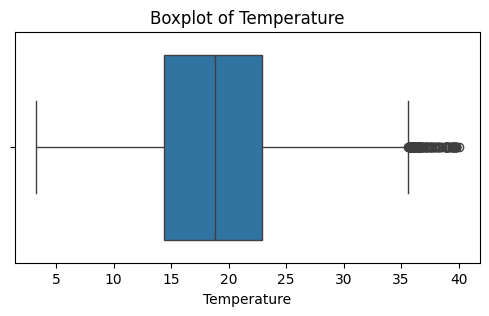

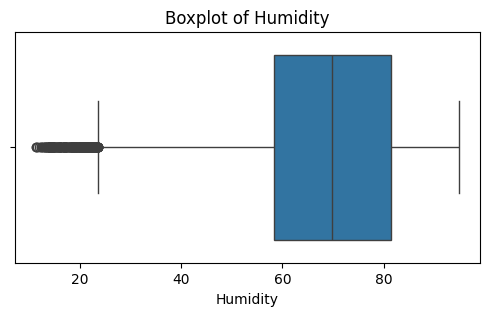

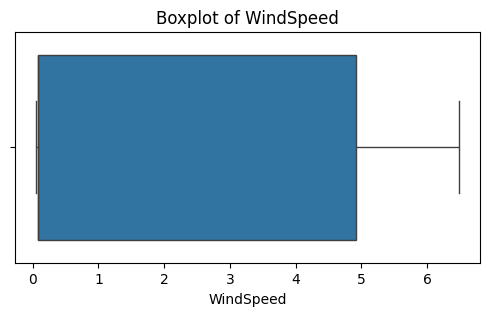

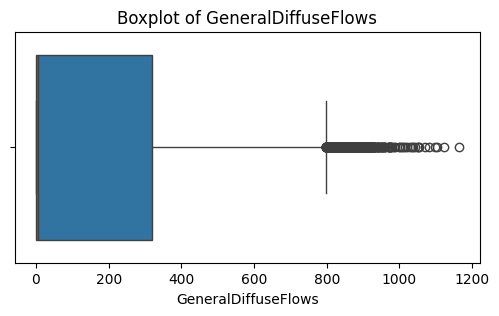

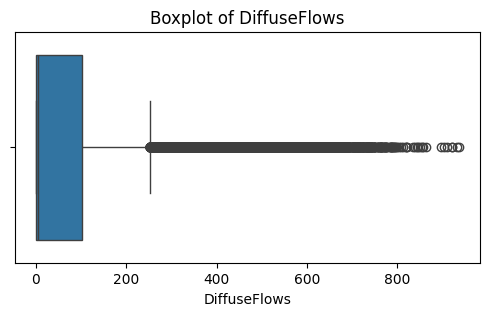

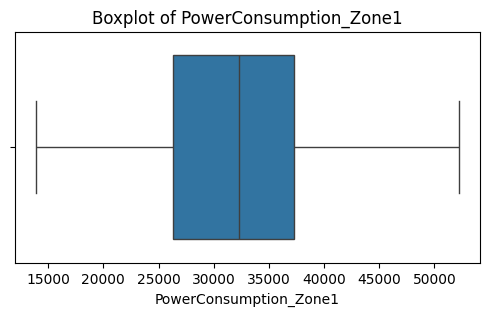

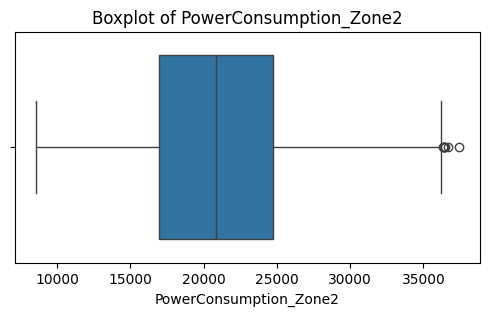

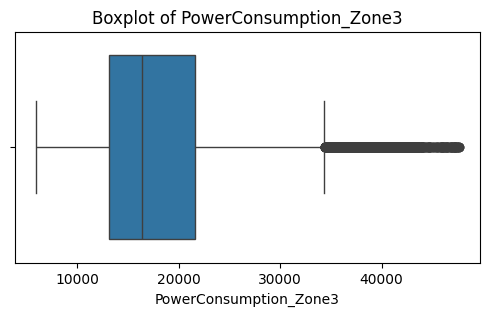

In [5]:
# Automatically select numerical columns for plotting
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Boxplots for Outlier Detection
print("Generating Boxplots...")
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()



Generating Scatter Plots...


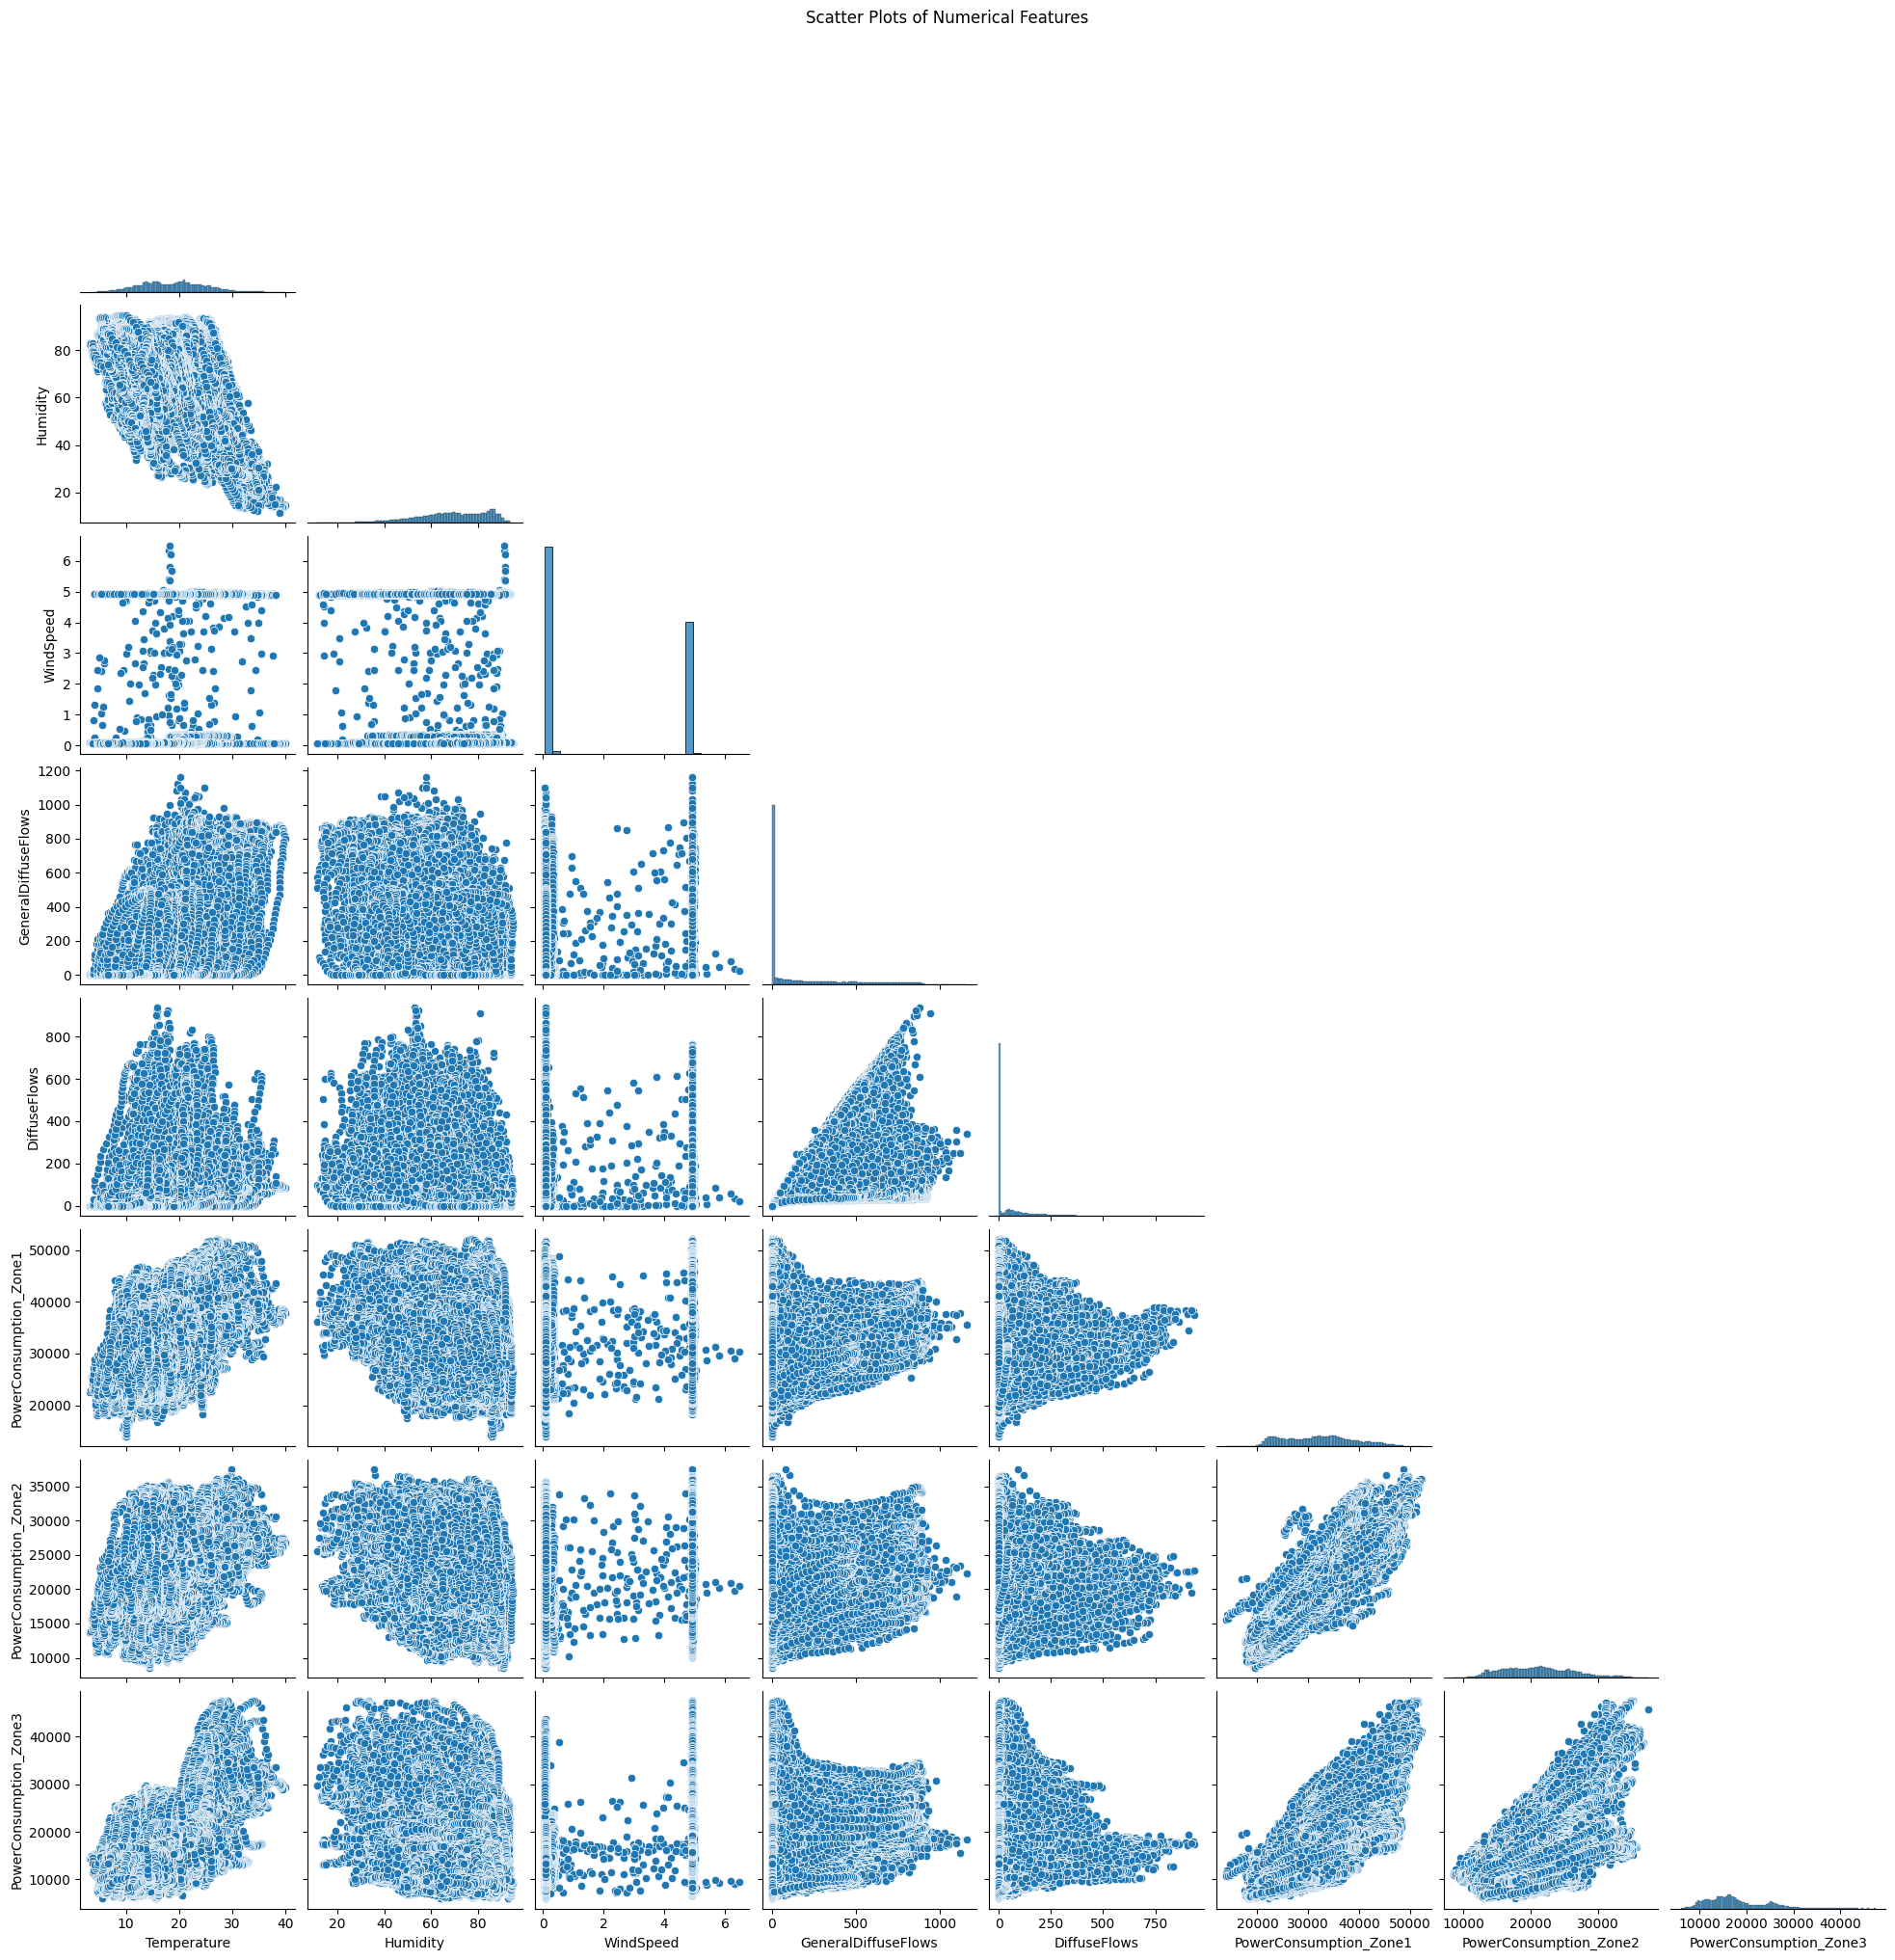

In [6]:
# Scatter Plots
print("Generating Scatter Plots...")
# We use a pairplot to show relationships across all numerical features
sns.pairplot(df[numeric_cols], corner=True)
plt.suptitle('Scatter Plots of Numerical Features', y=1.02)
plt.show()



Generating Histograms...


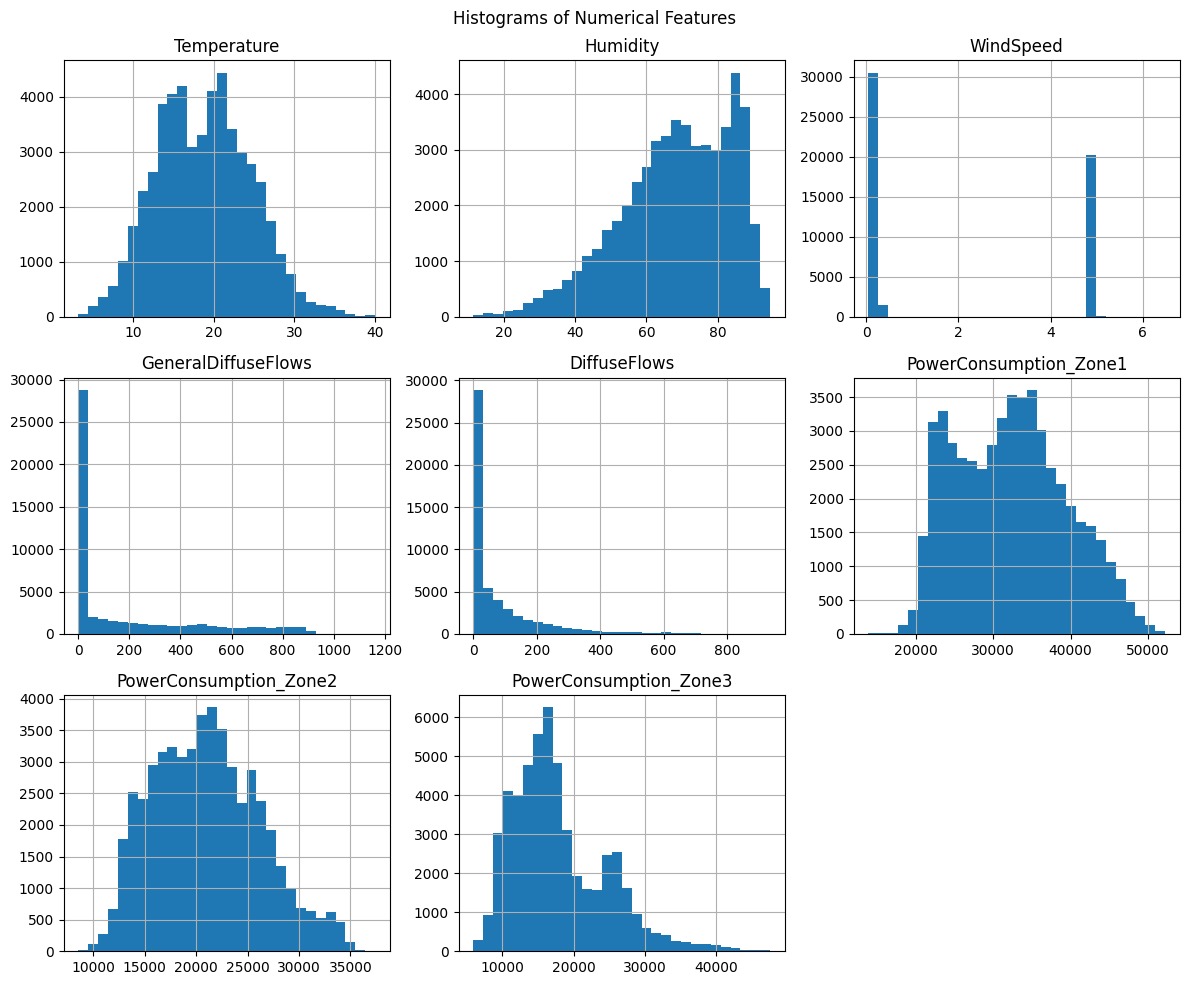

In [7]:
# Histograms
print("Generating Histograms...")
df[numeric_cols].hist(bins=30, figsize=(12, 10))
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()



Generating Correlation Heatmap...


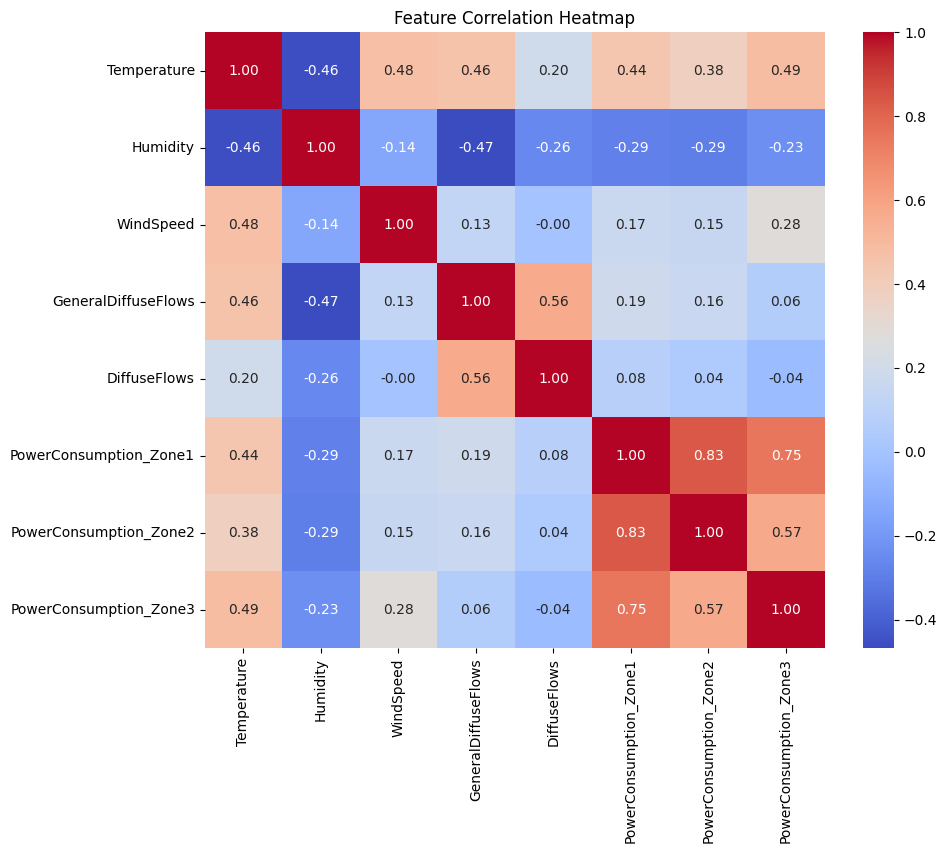

In [8]:
# Heatmap of Correlations
print("Generating Correlation Heatmap...")
plt.figure(figsize=(10, 8))
# Calculating the correlation matrix
corr_matrix = df[numeric_cols].corr()
# Plotting the heatmap using the 'coolwarm' color map as required by the lab
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Engineering


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# sort dataset chronologically
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

target_col = 'PowerConsumption_Zone1'
BASE_FEATURES = ["Temperature", "Humidity",
                 "WindSpeed", "GeneralDiffuseFlows",
                 "DiffuseFlows"]

# extract standard time features
df["Hour"]      = df["Datetime"].dt.hour
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"]     = df["Datetime"].dt.month
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

ALL_FEATURES = BASE_FEATURES + ["Hour", "DayOfWeek",
                                "Month", "IsWeekend"]

# create Weather Types for our stratified split
df['Weather_Type'] = pd.qcut(df['Temperature'], q=3, labels=['Cold', 'Mild', 'Hot'])

# scale the continuous features across the whole dataset first
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[ALL_FEATURES].values)

# build 3D sliding sequence matrix of the last 6 steps (1 Hour of history)
LOOKBACK = 6
X_3D_sequences = []
X_2D_snapshots = []
y_targets = []
weather_labels = []

# slide a window across the entire timeline
for i in range(LOOKBACK, len(df)):
    # 3D Sequence: The last 6 timesteps of weather history for Deep Learning
    X_3D_sequences.append(scaled_features[i-LOOKBACK:i, :])

    # 2D Snapshot: Just the single current timestep for Linear Regression / ANN
    X_2D_snapshots.append(scaled_features[i-1, :])

    y_targets.append(df.loc[i, target_col])
    weather_labels.append(df.loc[i, 'Weather_Type'])

X_3D_sequences = np.array(X_3D_sequences)
X_2D_snapshots = np.array(X_2D_snapshots)
y_targets = np.array(y_targets)
weather_labels = np.array(weather_labels)

# Perform the 80/20 Chronological Split WITHIN each weather type category
train_indices = []
test_indices = []

unique_types = ['Cold', 'Mild', 'Hot']
for w_type in unique_types:
    # Get indices matching this weather type
    group_indices = np.where(weather_labels == w_type)[0]
    split_point = int(len(group_indices) * 0.8)

    train_indices.extend(group_indices[:split_point])
    test_indices.extend(group_indices[split_point:])

# Final assignment of matrices for your individual training cells
X_train_scaled = X_2D_snapshots[train_indices]  # For Linear Regression & your ANN
X_test_scaled  = X_2D_snapshots[test_indices]   # For Linear Regression & your ANN

X_train_dl = X_3D_sequences[train_indices]      # For 1D CNN & CNN+LSTM (Samples, 6, 9)
X_test_dl  = X_3D_sequences[test_indices]       # For 1D CNN & CNN+LSTM (Samples, 6, 9)

y_train = y_targets[train_indices]
y_test  = y_targets[test_indices]

print("MULTI-TIMESTEP STRATIFIED SPLIT COMPLETE")
print(f"\n2D Tabular Shape (LR / ANN)  : {X_train_scaled.shape}")
print(f"3D Sequence Shape (DL Models): {X_train_dl.shape} -> (Samples, 6 Timesteps, 9 Features)")

MULTI-TIMESTEP STRATIFIED SPLIT COMPLETE

2D Tabular Shape (LR / ANN)  : (41926, 9)
3D Sequence Shape (DL Models): (41926, 6, 9) -> (Samples, 6 Timesteps, 9 Features)



## Traditional ML (Linear Regression)

In [10]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("Model trained successfully.")

Model trained successfully.


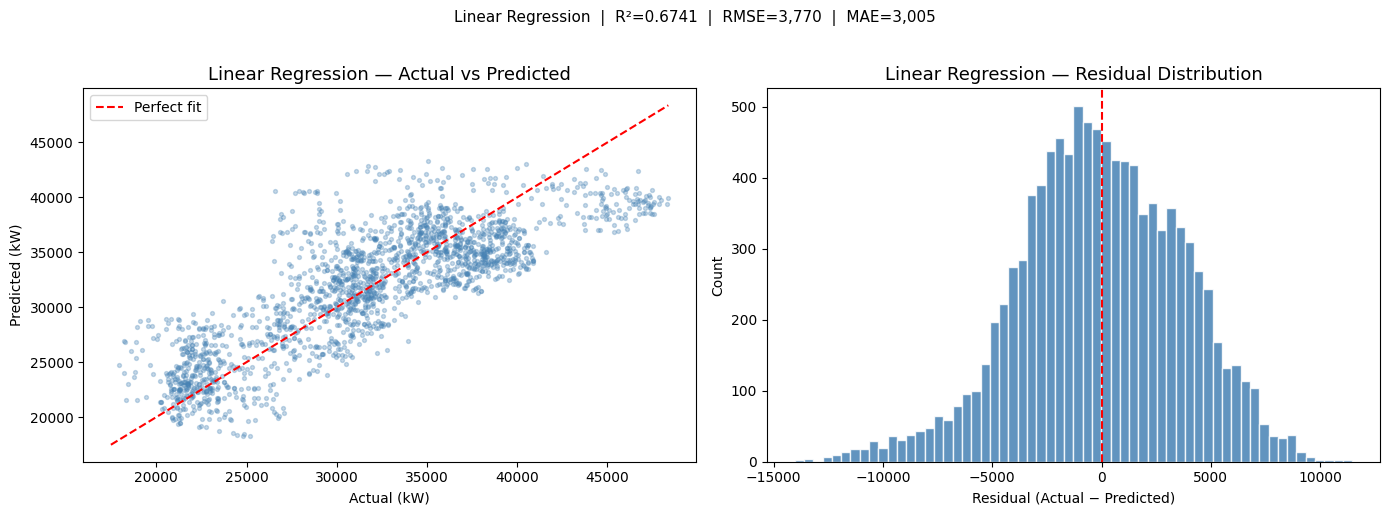

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate metrics and residuals
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_res = y_test - lr_pred

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)

# Figure 1: Actual vs Predicted
axes[0].scatter(y_test[sample], lr_pred[sample], alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), lr_pred.min()), max(y_test.max(), lr_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual (kW)"); axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title("Linear Regression — Actual vs Predicted", fontsize=13)
axes[0].legend()

# Figure 2: Residual distribution
axes[1].hist(lr_res, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel("Residual (Actual − Predicted)"); axes[1].set_ylabel("Count")
axes[1].set_title("Linear Regression — Residual Distribution", fontsize=13)

plt.suptitle(f"Linear Regression  |  R²={lr_r2:.4f}  |  RMSE={lr_rmse:,.0f}  |  MAE={lr_mae:,.0f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## Advanced ML (XGBoost) & Artificial Neural Network (MLP)





In [12]:
import xgboost as xgb

print("Training XGBoost Model...")

# Initialize and train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10.0,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

print("XGBoost trained successfully.")

Training XGBoost Model...
XGBoost trained successfully.


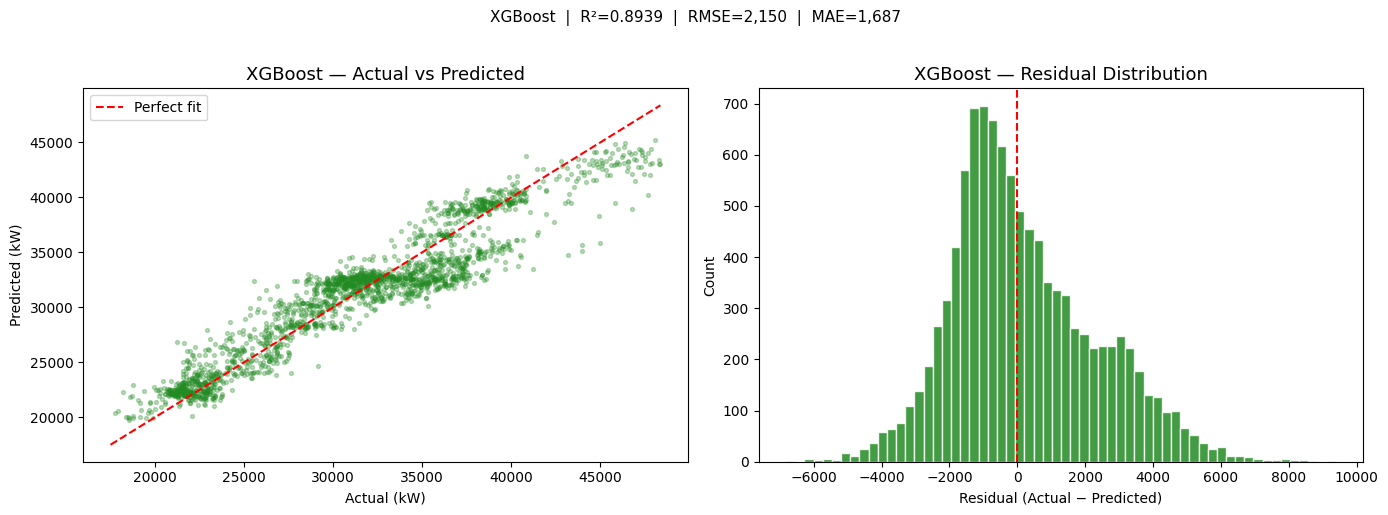

In [13]:
# Calculate metrics and residuals
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_res = y_test - xgb_pred

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)

# Figure 1: Actual vs Predicted
axes[0].scatter(y_test[sample], xgb_pred[sample], alpha=0.3, s=8, color='forestgreen')
lims = [min(y_test.min(), xgb_pred.min()), max(y_test.max(), xgb_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual (kW)"); axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title("XGBoost — Actual vs Predicted", fontsize=13)
axes[0].legend()

# Figure 2: Residual distribution
axes[1].hist(xgb_res, bins=60, color='forestgreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel("Residual (Actual − Predicted)"); axes[1].set_ylabel("Count")
axes[1].set_title("XGBoost — Residual Distribution", fontsize=13)

plt.suptitle(f"XGBoost  |  R²={xgb_r2:.4f}  |  RMSE={xgb_rmse:,.0f}  |  MAE={xgb_mae:,.0f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.neural_network import MLPRegressor

print("Training Artificial Neural Network (MLP)...")

# Initialize and train the ANN
# We use two hidden layers
# (64 neurons, then 32 neurons)
ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping= True
)

ann_model.fit(X_train_scaled, y_train)
ann_pred = ann_model.predict(X_test_scaled)

print("ANN trained successfully.")

Training Artificial Neural Network (MLP)...
ANN trained successfully.


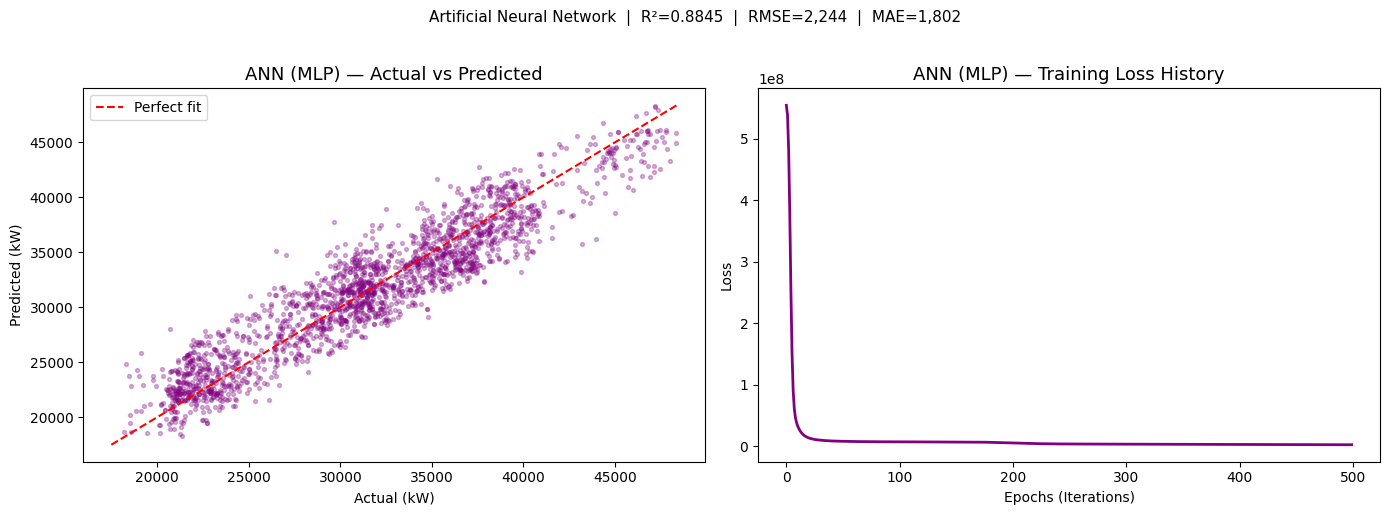

In [15]:
# Calculate metrics
ann_r2 = r2_score(y_test, ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_test, ann_pred))
ann_mae = mean_absolute_error(y_test, ann_pred)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)

# Figure 1: Actual vs Predicted
axes[0].scatter(y_test[sample], ann_pred[sample], alpha=0.3, s=8, color='purple')
lims = [min(y_test.min(), ann_pred.min()), max(y_test.max(), ann_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual (kW)"); axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title("ANN (MLP) — Actual vs Predicted", fontsize=13)
axes[0].legend()

# Figure 2: Training Loss History
axes[1].plot(ann_model.loss_curve_, color='purple', lw=2)
axes[1].set_xlabel("Epochs (Iterations)"); axes[1].set_ylabel("Loss")
axes[1].set_title("ANN (MLP) — Training Loss History", fontsize=13)

plt.suptitle(f"Artificial Neural Network  |  R²={ann_r2:.4f}  |  RMSE={ann_rmse:,.0f}  |  MAE={ann_mae:,.0f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


## Deep Learning: 1D Convolutional Neural Network (CNN)


In [16]:
from keras import Sequential
from keras.layers import Dense, Conv1D, Flatten, LSTM, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

print("Reshaping data and training 1D CNN...")

# Reshape 2D tabular data into 3D for Deep Learning: (samples, timesteps, features)
# We treat the entire row of features as 1 timestep.
X_train_dl = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_dl  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build 1D CNN Architecture
cnn_model = Sequential([
    Conv1D(filters=64,
           kernel_size=1,
           activation='relu',
           input_shape=(1, X_train_scaled.shape[1])),
    Flatten(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
cnn_history = cnn_model.fit(
    X_train_dl, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Predict (and flatten back to a 1D array to match y_test)
cnn_pred = cnn_model.predict(X_test_dl).flatten()

print("1D CNN trained successfully.")

Reshaping data and training 1D CNN...
Epoch 1/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 752404416.0000 - val_loss: 478333536.0000
Epoch 2/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 95848600.0000 - val_loss: 65853972.0000
Epoch 3/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 45516608.0000 - val_loss: 37115060.0000
Epoch 4/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 34152160.0000 - val_loss: 27878426.0000
Epoch 5/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 29702678.0000 - val_loss: 24286388.0000
Epoch 6/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 27683544.0000 - val_loss: 22435056.0000
Epoch 7/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 26775542.0000 - val_loss: 21240726.0000
Epoch 8/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 25971412.0000 - val_loss: 20560242.0000
Epoch 9/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 25310110.0000 - val_loss: 19968232.0000
Epoch 10/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━

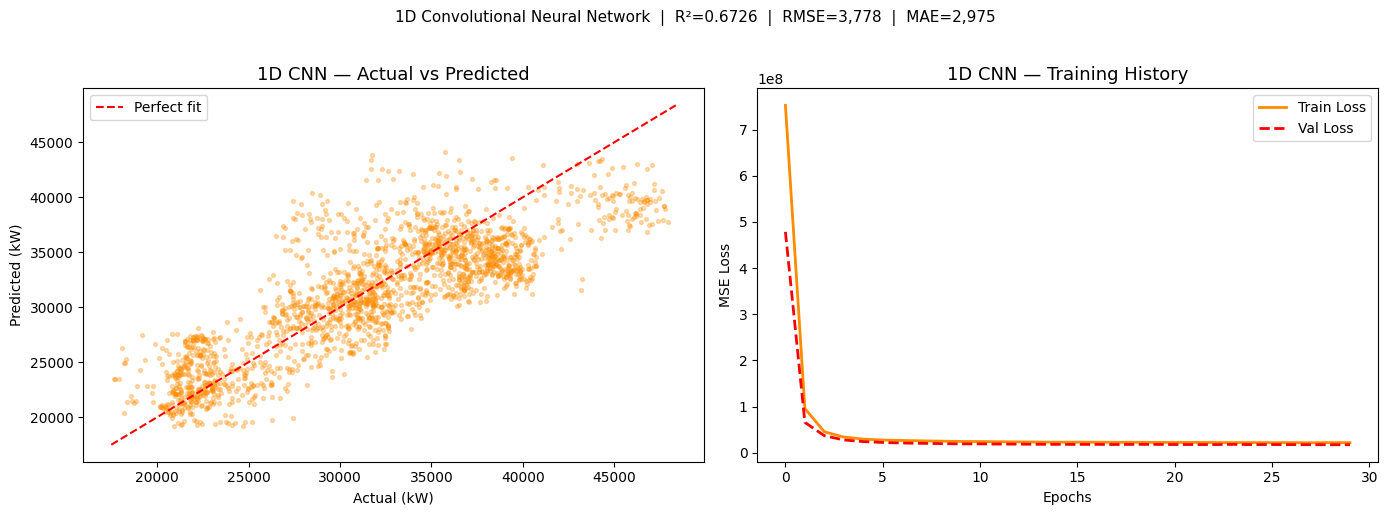

In [17]:
# Calculate metrics
cnn_r2 = r2_score(y_test, cnn_pred)
cnn_rmse = np.sqrt(mean_squared_error(y_test, cnn_pred))
cnn_mae = mean_absolute_error(y_test, cnn_pred)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)

# Figure 1: Actual vs Predicted
axes[0].scatter(y_test[sample], cnn_pred[sample], alpha=0.3, s=8, color='darkorange')
lims = [min(y_test.min(), cnn_pred.min()), max(y_test.max(), cnn_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual (kW)"); axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title("1D CNN — Actual vs Predicted", fontsize=13)
axes[0].legend()

# Figure 2: Training & Validation Loss
axes[1].plot(cnn_history.history['loss'], label='Train Loss', color='darkorange', lw=2)
axes[1].plot(cnn_history.history['val_loss'], label='Val Loss', color='red', lw=2, linestyle='--')
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("MSE Loss")
axes[1].set_title("1D CNN — Training History", fontsize=13)
axes[1].legend()

plt.suptitle(f"1D Convolutional Neural Network  |  R²={cnn_r2:.4f}  |  RMSE={cnn_rmse:,.0f}  |  MAE={cnn_mae:,.0f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Deep Learning: CNN + LSTM Hybrid


In [18]:
print("Training CNN + LSTM Hybrid Model...")

# Build Hybrid Architecture
hybrid_model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, X_train_scaled.shape[1])),
    LSTM(32,kernel_regularizer=l2(1e-4),activation='relu'), # LSTM handles the sequential aspect inherently
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

hybrid_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the model
hybrid_history = hybrid_model.fit(
    X_train_dl, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

# Predict
hybrid_pred = hybrid_model.predict(X_test_dl).flatten()

print("CNN + LSTM trained successfully.")

Training CNN + LSTM Hybrid Model...
Epoch 1/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 355820928.0000 - val_loss: 40372116.0000
Epoch 2/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 37073204.0000 - val_loss: 24230868.0000
Epoch 3/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 30995104.0000 - val_loss: 21177982.0000
Epoch 4/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 29364370.0000 - val_loss: 19504264.0000
Epoch 5/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 28268210.0000 - val_loss: 17864046.0000
Epoch 6/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 27491784.0000 - val_loss: 17681506.0000
Epoch 7/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 26892426.0000 - val_loss: 17507278.0000
Epoch 8/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 26156654.0000 - val_loss: 15927765.0000
Epoch 9/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 25253298.0000 - val_loss: 15907043.0000
Epoch 10/30
1180/1180 ━━━━━━━━━━━━━━━━━━━━ 4s

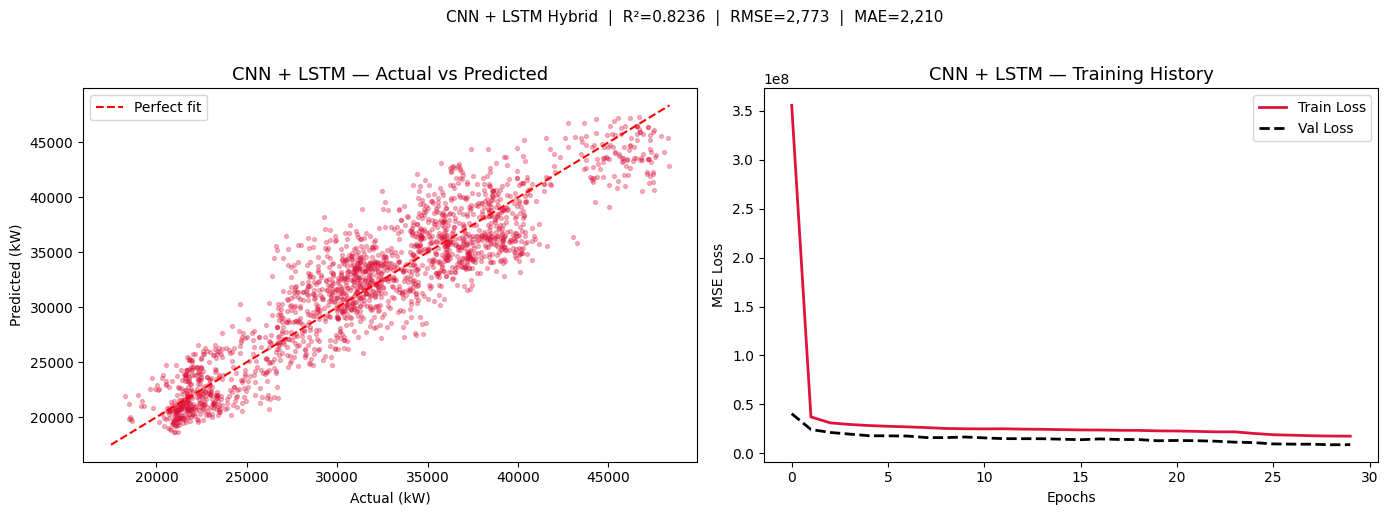

In [19]:
# Calculate metrics
hybrid_r2 = r2_score(y_test, hybrid_pred)
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
hybrid_mae = mean_absolute_error(y_test, hybrid_pred)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)

# Figure 1: Actual vs Predicted
axes[0].scatter(y_test[sample], hybrid_pred[sample], alpha=0.3, s=8, color='crimson')
lims = [min(y_test.min(), hybrid_pred.min()), max(y_test.max(), hybrid_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual (kW)"); axes[0].set_ylabel("Predicted (kW)")
axes[0].set_title("CNN + LSTM — Actual vs Predicted", fontsize=13)
axes[0].legend()

# Figure 2: Training & Validation Loss
axes[1].plot(hybrid_history.history['loss'], label='Train Loss', color='crimson', lw=2)
axes[1].plot(hybrid_history.history['val_loss'], label='Val Loss', color='black', lw=2, linestyle='--')
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("MSE Loss")
axes[1].set_title("CNN + LSTM — Training History", fontsize=13)
axes[1].legend()

plt.suptitle(f"CNN + LSTM Hybrid  |  R²={hybrid_r2:.4f}  |  RMSE={hybrid_rmse:,.0f}  |  MAE={hybrid_mae:,.0f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Evaluation & Visualisation


FINAL MODEL LEADERBOARD (Ranked by R²)


,R2,RMSE,MAE
Model,,,
XGBoost,0.893948,2150.341702,1687.470138
ANN (MLP),0.884532,2243.772973,1802.174317
CNN + LSTM,0.823613,2773.195702,2209.542127
Linear Regression,0.674074,3769.697953,3004.898236
1D CNN,0.672610,3778.160079,2974.715215


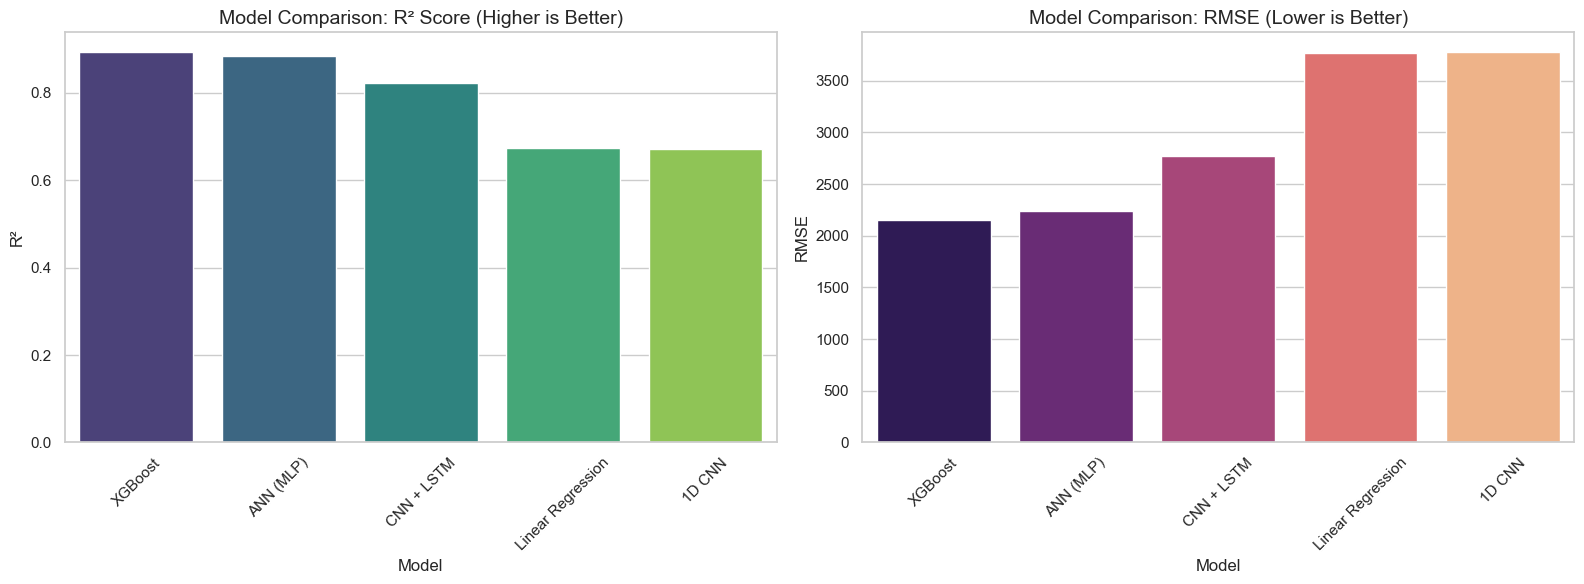

In [20]:
# Ensure the evaluate_model function from the earlier draft is loaded
def calculate_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

# Gather all predictions
model_preds = {
    "Linear Regression": lr_pred,
    "XGBoost": xgb_pred,
    "ANN (MLP)": ann_pred,
    "1D CNN": cnn_pred,
    "CNN + LSTM": hybrid_pred
}

# Conditionally add CNN + LSTM predictions if the model was run
if 'hybrid_pred' in globals():
    model_preds["CNN + LSTM"] = hybrid_pred

# Build Leaderboard
results = []
for name, preds in model_preds.items():
    metrics = calculate_metrics(y_test, preds)
    metrics['Model'] = name
    results.append(metrics)

leaderboard = pd.DataFrame(results).set_index('Model').sort_values(by='R2', ascending=False)

print("=======================================================")
print("FINAL MODEL LEADERBOARD (Ranked by R²)")
print("=======================================================")
display(leaderboard)
print("=======================================================\n")

# ── Visualisation ──
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R2 Comparison
sns.barplot(x=leaderboard.index, y=leaderboard['R2'], ax=axes[0], palette="viridis")
axes[0].set_title("Model Comparison: R² Score (Higher is Better)", fontsize=14)
axes[0].set_ylabel("R²")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: RMSE Comparison
sns.barplot(x=leaderboard.index, y=leaderboard['RMSE'], ax=axes[1], palette="magma")
axes[1].set_title("Model Comparison: RMSE (Lower is Better)", fontsize=14)
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Saving All Trained Models and Scalar to Deploy

In [21]:
import joblib
import os

# Define the directory to save models
MODELS_DIR = 'trained_models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Save all trained models and the scaler if they exist
models_to_save = {
    'linear_regression_model': 'lr_model',
    'xgboost_model': 'xgb_model',
    'ann_model': 'ann_model',
    'cnn_model': 'cnn_model',
    'hybrid_model': 'hybrid_model',
    'scaler': 'scaler'
}

for filename_prefix, model_var_name in models_to_save.items():
    if model_var_name in globals(): # Check if the variable exists
        obj = globals()[model_var_name]
        obj_filename = os.path.join(MODELS_DIR, f'{filename_prefix}.joblib')
        joblib.dump(obj, obj_filename)
        print(f"{model_var_name} saved to {obj_filename}")
    else:
        print(f"Warning: {model_var_name} not found in globals, skipping save.")

print("\nAll available models and the scaler have been saved.")

lr_model saved to trained_models\linear_regression_model.joblib
xgb_model saved to trained_models\xgboost_model.joblib
ann_model saved to trained_models\ann_model.joblib
cnn_model saved to trained_models\cnn_model.joblib
hybrid_model saved to trained_models\hybrid_model.joblib
scaler saved to trained_models\scaler.joblib

All available models and the scaler have been saved.
